# Οπτικοποίηση Αρχιτεκτονικής Κβαντικού Κυκλώματος (VQC)

Στο παρακάτω κελί, απομονώνουμε αποκλειστικά τον κώδικα που κατασκευάζει την αρχιτεκτονική του κβαντικού μας μοντέλου. Σκοπός είναι να εξαγάγουμε το σχεδιάγραμμα του κυκλώματος **χωρίς να χρειαστεί να εκτελέσουμε ξανά την εξαιρετικά χρονοβόρα διαδικασία της εκπαίδευσης (training)** ή να φορτώσουμε το πλήρες dataset.

Για να επιτευχθεί αυτό με αυτόνομο τρόπο, χρησιμοποιούμε τα εξής:
* **State Preparation (Amplitude Encoding):** Δημιουργούμε ένα "εικονικό" (dummy) κανονικοποιημένο διάνυσμα 16 διαστάσεων. Η Qiskit χρειάζεται απλώς τις σωστές διαστάσεις για να "χτίσει" το block, οπότε δεν απαιτούνται τα πραγματικά δεδομένα του NSL-KDD.
* **Feature Map & Ansatz:** Ενώνουμε το `raw_feature_vector` (16 features) με το `RealAmplitudes` ansatz (4 qubits, reps=5), διατηρώντας ακριβώς την ίδια δομή που είχε το τελικό μας μοντέλο.


--- 1. Οπτικοποίηση State Preparation (Στο βαθύτερο επίπεδο) ---


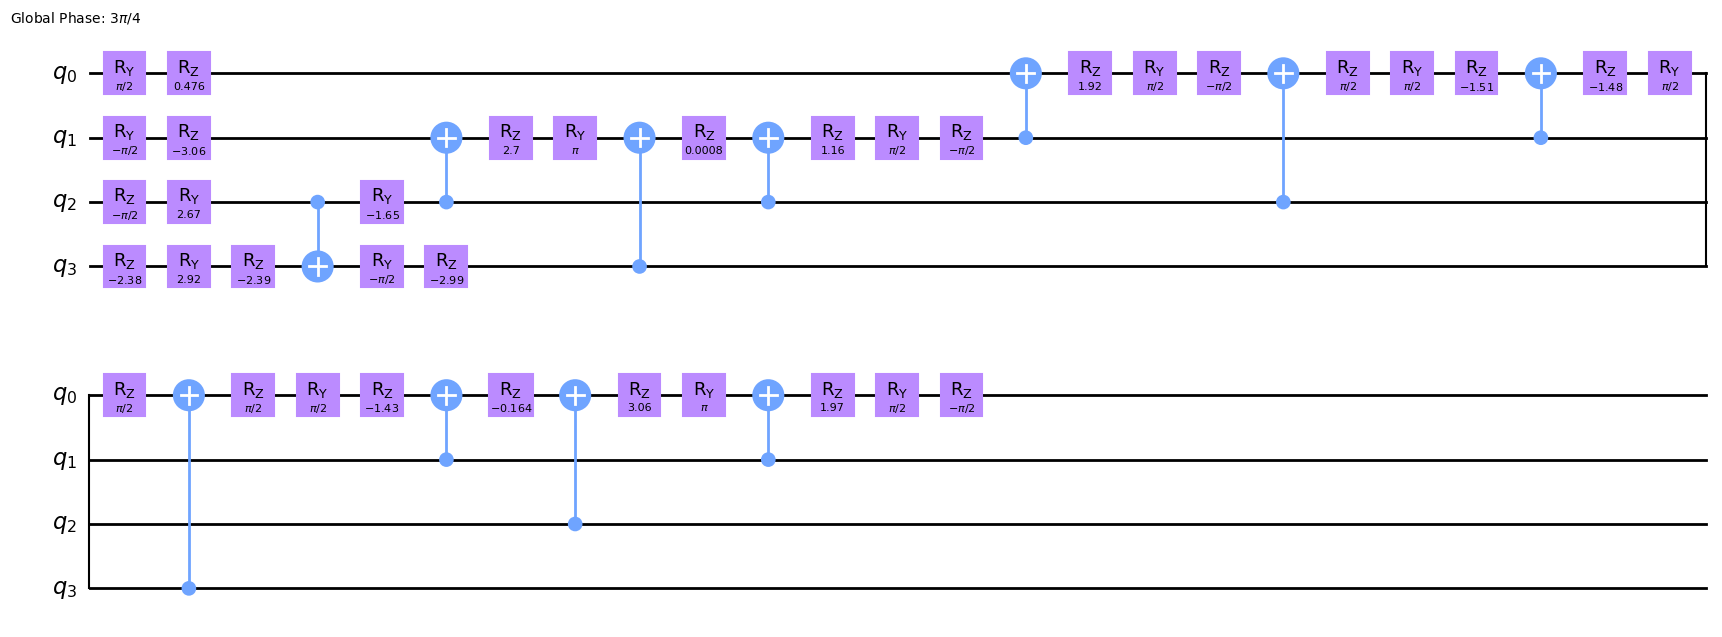


--- 2. Δομή VQC (Feature Map + Ansatz) (Αναλυτικά) ---
Απαιτούμενα Qubits: 4
Αριθμός παραμέτρων ansatz: 40


/tmp/ipykernel_11147/1850069943.py:33: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_amp = RealAmplitudes(num_qubits=4, reps=5)


QiskitError: 'Cannot define a ParameterizedInitialize with unbound parameters'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, RealAmplitudes
from qiskit_machine_learning.circuit.library import raw_feature_vector

print("--- 1. Οπτικοποίηση State Preparation (Στο βαθύτερο επίπεδο) ---")
num_qubits = 4

# Δημιουργούμε ένα τυχαίο κανονικοποιημένο διάνυσμα 16 διαστάσεων 
dummy_data = np.random.rand(16)
dummy_data = dummy_data / np.linalg.norm(dummy_data) 

state_prep = StatePreparation(dummy_data)
qc = QuantumCircuit(num_qubits, name="Amplitude encoding")
qc.append(state_prep, range(num_qubits))

# Χρησιμοποιούμε transpile για να το "σπάσουμε" στις πιο βασικές πύλες που υπάρχουν
# (CNOTs, και περιστροφές U ή R)
qc_decomposed = transpile(qc, basis_gates=['cx', 'ry', 'rz', 'h'])
display(qc_decomposed.draw(output='mpl', style='clifford'))


print("\n--- 2. Δομή VQC (Feature Map + Ansatz) (Αναλυτικά) ---")

# Feature Map (16 διαστάσεις)
feature_vector_circuit = raw_feature_vector(feature_dimension=16)

# Ansatz (RealAmplitudes με reps=5)
ansatz_amp = RealAmplitudes(num_qubits=4, reps=5)

# Ένωση (Compose) των δύο μερών
vqc_amp = feature_vector_circuit.compose(ansatz_amp)

print(f'Απαιτούμενα Qubits: {vqc_amp.num_qubits}')
print(f'Αριθμός παραμέτρων ansatz: {vqc_amp.num_parameters}')

# Εδώ προσθέτουμε το .decompose(reps=2) για να δούμε τα CNOTs και τα Ry gates!
fig = vqc_amp.decompose(reps=2).draw(output='mpl', style='clifford')
display(fig)